# 06 — Predict Current Playoffs (2025-26 Second Round)

Apply the trained XGBoost series model to the live second-round matchups.

**Model trained on:** 2015–2022 | **Validated on:** 2023–24 (AUC 0.683)

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, str(Path().resolve().parent))
from src.data import _HEADERS
from src.models import load_model

In [2]:
# ── CONFIG ────────────────────────────────────────────────────
CURRENT_SEASON = "2025-26"
RAW_DIR        = Path().resolve().parent / "data" / "raw"

# Second-round matchups: (higher_seed_name, higher_seed_id, lower_seed_name, lower_seed_id, series_score)
# Higher seed = team hosting games 1 & 2
MATCHUPS = [
    # East
    ("New York Knicks",       1610612752, "Philadelphia 76ers",   1610612755, "Active"),
    ("Detroit Pistons",       1610612765, "Cleveland Cavaliers",  1610612739, "Active"),
    # West
    ("Oklahoma City Thunder", 1610612760, "Los Angeles Lakers",   1610612747, "Active"),
    ("San Antonio Spurs",     1610612759, "Minnesota Timberwolves",1610612750, "Active"),
]

FEATURE_COLS = [
    "home_ortg", "away_ortg", "home_drtg", "away_drtg",
    "home_net_rtg", "away_net_rtg", "net_rtg_diff",
    "home_pace", "away_pace", "ortg_diff", "drtg_diff",
    "home_win_pct", "away_win_pct", "win_pct_diff",
    "home_oreb_pct", "away_oreb_pct",
    "home_tov_pct", "away_tov_pct",
    "home_playoff_win_pct_3yr", "away_playoff_win_pct_3yr", "playoff_win_pct_diff",
    "home_finals_apps_5yr", "away_finals_apps_5yr",
]

## 1. Fetch Current Season Team Metrics

Falls back to 2023-24 if stats.nba.com is unavailable.

In [3]:
cache_current = RAW_DIR / f"team_metrics_{CURRENT_SEASON}.parquet"

if cache_current.exists():
    metrics = pd.read_parquet(cache_current)
    metrics_season = CURRENT_SEASON
    print(f"Loaded cached {CURRENT_SEASON} metrics")
else:
    # stats.nba.com blocks automated requests — use most recent cached season as proxy
    metrics = pd.read_parquet(RAW_DIR / "team_metrics_2023-24.parquet")
    metrics_season = "2023-24 (proxy)"
    print("Using 2023-24 metrics as proxy for 2025-26 (stats.nba.com unavailable)")

eff = metrics.set_index("TEAM_ID")
print(f"\nMetrics season: {metrics_season}")
eff[["TEAM_NAME", "E_NET_RATING", "E_OFF_RATING", "E_DEF_RATING", "W_PCT"]].sort_values("E_NET_RATING", ascending=False).head(8)

Using 2023-24 metrics as proxy for 2025-26 (stats.nba.com unavailable)

Metrics season: 2023-24 (proxy)


,TEAM_NAME,E_NET_RATING,E_OFF_RATING,E_DEF_RATING,W_PCT
TEAM_ID,,,,,
1610612738,Boston Celtics,11.3,120.2,108.9,0.780
1610612760,Oklahoma City Thunder,7.2,117.0,109.8,0.695
1610612750,Minnesota Timberwolves,6.5,113.1,106.6,0.683
1610612743,Denver Nuggets,5.3,115.6,110.3,0.695
1610612752,New York Knicks,4.6,114.1,109.5,0.610
1610612740,New Orleans Pelicans,4.4,115.0,110.6,0.598
1610612746,LA Clippers,3.3,116.1,112.8,0.622
1610612756,Phoenix Suns,3.0,114.9,111.9,0.598


## 2. Historical Features (from 2022–2024 playoff data)

In [4]:
hist_games = pd.concat(
    [pd.read_parquet(RAW_DIR / f"playoff_games_{s}.parquet").assign(season=s)
     for s in ["2021-22", "2022-23", "2023-24"]],
    ignore_index=True,
)
hist_games["round"] = hist_games["GAME_ID"].str[6:8].astype(int)
hist_games["win"]   = (hist_games["WL"] == "W").astype(int)
hist_games["is_finals"] = (hist_games["round"] == 4).astype(int)

season_stats = hist_games.groupby(["season", "TEAM_ID"]).agg(
    playoff_wins=("win", "sum"),
    playoff_games=("win", "count"),
    reached_finals=("is_finals", "max"),
).reset_index()
season_stats["playoff_win_pct"] = season_stats["playoff_wins"] / season_stats["playoff_games"]
season_stats["season_year"] = season_stats["season"].str[:4].astype(int)

def prior_stats(team_id, current_year=2025):
    hist = season_stats[season_stats["TEAM_ID"] == team_id]
    p3   = hist[hist["season_year"] >= current_year - 3]
    p5   = hist[hist["season_year"] >= current_year - 5]
    return (
        round(p3["playoff_win_pct"].mean(), 3) if len(p3) > 0 else 0.5,
        int(p5["reached_finals"].sum()),
    )

print("Historical data loaded")

Historical data loaded


## 3. Build Features + Predict

In [5]:
pipeline = load_model("series_xgboost")
rows = []

for h_name, h_id, a_name, a_id, score in MATCHUPS:
    h = eff.loc[h_id]
    a = eff.loc[a_id]
    h_hist, h_finals = prior_stats(h_id)
    a_hist, a_finals = prior_stats(a_id)

    rows.append({
        "matchup":      f"{h_name} vs {a_name}",
        "series_score": score,
        "home_ortg":    h["E_OFF_RATING"], "away_ortg":    a["E_OFF_RATING"],
        "home_drtg":    h["E_DEF_RATING"], "away_drtg":    a["E_DEF_RATING"],
        "home_net_rtg": h["E_NET_RATING"], "away_net_rtg": a["E_NET_RATING"],
        "net_rtg_diff": h["E_NET_RATING"] - a["E_NET_RATING"],
        "home_pace":    h["E_PACE"],       "away_pace":    a["E_PACE"],
        "ortg_diff":    h["E_OFF_RATING"] - a["E_OFF_RATING"],
        "drtg_diff":    h["E_DEF_RATING"] - a["E_DEF_RATING"],
        "home_win_pct": h["W_PCT"],        "away_win_pct": a["W_PCT"],
        "win_pct_diff": h["W_PCT"] - a["W_PCT"],
        "home_oreb_pct":h["E_OREB_PCT"],   "away_oreb_pct":a["E_OREB_PCT"],
        "home_tov_pct": h["E_TM_TOV_PCT"], "away_tov_pct": a["E_TM_TOV_PCT"],
        "home_playoff_win_pct_3yr": h_hist, "away_playoff_win_pct_3yr": a_hist,
        "playoff_win_pct_diff":     h_hist - a_hist,
        "home_finals_apps_5yr":     h_finals, "away_finals_apps_5yr": a_finals,
    })

pred_df  = pd.DataFrame(rows)
probs    = pipeline.predict_proba(pred_df[FEATURE_COLS])[:, 1]
pred_df["prob_higher_seed"] = probs
pred_df["predicted_winner"] = pred_df.apply(
    lambda r: r["matchup"].split(" vs ")[0] if r["prob_higher_seed"] >= 0.5
              else r["matchup"].split(" vs ")[1], axis=1
)
pred_df["confidence"] = pred_df["prob_higher_seed"].apply(lambda p: f"{max(p, 1-p):.0%}")

print(f"=== 2025-26 NBA Playoffs — Second Round Predictions ===")
print(f"(Team metrics from: {metrics_season})")
print()
for _, r in pred_df.iterrows():
    print(f"  {r['matchup']}")
    print(f"  → {r['predicted_winner']}  ({r['confidence']} confidence)")
    print()

=== 2025-26 NBA Playoffs — Second Round Predictions ===
(Team metrics from: 2023-24 (proxy))

  New York Knicks vs Philadelphia 76ers
  → New York Knicks  (97% confidence)

  Detroit Pistons vs Cleveland Cavaliers
  → Detroit Pistons  (78% confidence)

  Oklahoma City Thunder vs Los Angeles Lakers
  → Oklahoma City Thunder  (98% confidence)

  San Antonio Spurs vs Minnesota Timberwolves
  → San Antonio Spurs  (81% confidence)



## 4. Probability Chart

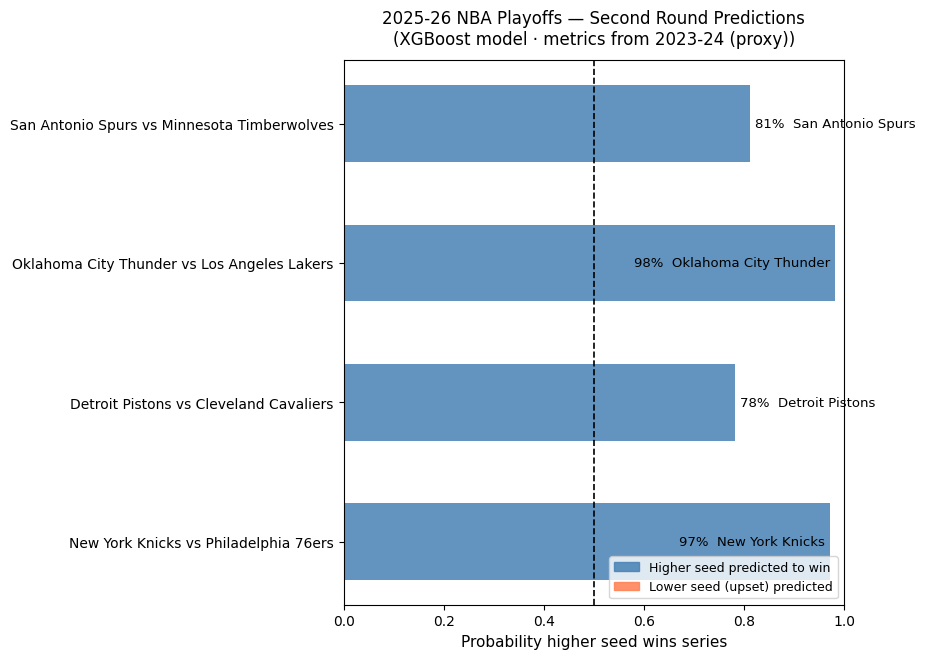

Saved → /Users/mearly/dev/playground/Sports/nba-playoffs/predictions_r2_2025-26.png


In [6]:
fig, ax = plt.subplots(figsize=(9, len(pred_df) * 1.3 + 1.5))

colors = ["steelblue" if p >= 0.5 else "coral" for p in pred_df["prob_higher_seed"]]
bars   = ax.barh(pred_df["matchup"], pred_df["prob_higher_seed"], color=colors, alpha=0.85, height=0.55)

ax.axvline(0.5, color="black", linewidth=1.2, linestyle="--")
ax.set_xlim(0, 1)
ax.set_xlabel("Probability higher seed wins series", fontsize=11)
ax.set_title(f"2025-26 NBA Playoffs — Second Round Predictions\n(XGBoost model · metrics from {metrics_season})",
             fontsize=12, pad=12)

for bar, prob, name in zip(bars, pred_df["prob_higher_seed"], pred_df["predicted_winner"]):
    offset = 0.01 if prob < 0.88 else -0.01
    ha     = "left" if prob < 0.88 else "right"
    ax.text(prob + offset, bar.get_y() + bar.get_height() / 2,
            f"{prob:.0%}  {name}", va="center", ha=ha, fontsize=9.5)

higher = mpatches.Patch(color="steelblue", alpha=0.85, label="Higher seed predicted to win")
lower  = mpatches.Patch(color="coral",     alpha=0.85, label="Lower seed (upset) predicted")
ax.legend(handles=[higher, lower], loc="lower right", fontsize=9)

plt.tight_layout()
out_path = Path().resolve().parent / "predictions_r2_2025-26.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

## 5. Conference Finals Projection

In [7]:
# ── helpers reused for CF and Finals ────────────────────────
def build_row(h_name, h_id, a_name, a_id):
    h = eff.loc[h_id];  a = eff.loc[a_id]
    h_hist, h_fin = prior_stats(h_id)
    a_hist, a_fin = prior_stats(a_id)
    return {
        "matchup":                      f"{h_name} vs {a_name}",
        "home_ortg":    h["E_OFF_RATING"], "away_ortg":    a["E_OFF_RATING"],
        "home_drtg":    h["E_DEF_RATING"], "away_drtg":    a["E_DEF_RATING"],
        "home_net_rtg": h["E_NET_RATING"], "away_net_rtg": a["E_NET_RATING"],
        "net_rtg_diff": h["E_NET_RATING"] - a["E_NET_RATING"],
        "home_pace":    h["E_PACE"],       "away_pace":    a["E_PACE"],
        "ortg_diff":    h["E_OFF_RATING"] - a["E_OFF_RATING"],
        "drtg_diff":    h["E_DEF_RATING"] - a["E_DEF_RATING"],
        "home_win_pct": h["W_PCT"],        "away_win_pct": a["W_PCT"],
        "win_pct_diff": h["W_PCT"] - a["W_PCT"],
        "home_oreb_pct":h["E_OREB_PCT"],   "away_oreb_pct":a["E_OREB_PCT"],
        "home_tov_pct": h["E_TM_TOV_PCT"], "away_tov_pct": a["E_TM_TOV_PCT"],
        "home_playoff_win_pct_3yr": h_hist, "away_playoff_win_pct_3yr": a_hist,
        "playoff_win_pct_diff":     h_hist - a_hist,
        "home_finals_apps_5yr":     h_fin,  "away_finals_apps_5yr": a_fin,
    }

def predict_round(matchup_list):
    rows = [build_row(*m) for m in matchup_list]
    df   = pd.DataFrame(rows)
    df["prob_higher_seed"] = pipeline.predict_proba(df[FEATURE_COLS])[:, 1]
    df["predicted_winner"] = df.apply(
        lambda r: r["matchup"].split(" vs ")[0] if r["prob_higher_seed"] >= 0.5
                  else r["matchup"].split(" vs ")[1], axis=1
    )
    df["confidence"] = df["prob_higher_seed"].apply(lambda p: f"{max(p, 1-p):.0%}")
    return df

def advance(h_name, h_id, a_name, a_id, prob):
    """Return (winner_name, winner_id) for a matchup given P(higher seed wins)."""
    return (h_name, h_id) if prob >= 0.5 else (a_name, a_id)

# ── R2 bracket positions (mirrors MATCHUPS order) ───────────
# (h_name, h_id, a_name, a_id)
R2 = [
    ("New York Knicks",        1610612752, "Philadelphia 76ers",    1610612755),  # East top
    ("Detroit Pistons",        1610612765, "Cleveland Cavaliers",   1610612739),  # East bottom
    ("Oklahoma City Thunder",  1610612760, "Los Angeles Lakers",    1610612747),  # West top
    ("San Antonio Spurs",      1610612759, "Minnesota Timberwolves",1610612750),  # West bottom
]
r2_p = pred_df["prob_higher_seed"].values

east0 = advance(*R2[0], r2_p[0])   # East top-bracket winner  (1-seed path)
east1 = advance(*R2[1], r2_p[1])   # East bottom-bracket winner
west0 = advance(*R2[2], r2_p[2])   # West top-bracket winner  (1-seed path)
west1 = advance(*R2[3], r2_p[3])   # West bottom-bracket winner

# CF: top-bracket winner hosts (higher seed in each conference)
cf_matchups = [(*east0, *east1), (*west0, *west1)]
cf_df = predict_round(cf_matchups)

print("=== Conference Finals Predictions (projected) ===\n")
for (_, r), conf in zip(cf_df.iterrows(), ["East CF", "West CF"]):
    print(f"  {conf}: {r['matchup']}")
    print(f"  → {r['predicted_winner']}  ({r['confidence']} confidence)\n")

=== Conference Finals Predictions (projected) ===

  East CF: New York Knicks vs Detroit Pistons
  → New York Knicks  (99% confidence)

  West CF: Oklahoma City Thunder vs San Antonio Spurs
  → Oklahoma City Thunder  (99% confidence)



## 6. NBA Finals Projection

In [8]:
east_winner = advance(*cf_matchups[0], cf_df["prob_higher_seed"].iloc[0])
west_winner = advance(*cf_matchups[1], cf_df["prob_higher_seed"].iloc[1])

# Home court in Finals: team with higher net rating hosts games 1 & 2
if eff.loc[west_winner[1]]["E_NET_RATING"] >= eff.loc[east_winner[1]]["E_NET_RATING"]:
    finals_h, finals_a = west_winner, east_winner
else:
    finals_h, finals_a = east_winner, west_winner

finals_df = predict_round([(*finals_h, *finals_a)])

r = finals_df.iloc[0]
print("=== NBA Finals Prediction (projected) ===\n")
print(f"  {r['matchup']}")
print(f"  → {r['predicted_winner']}  ({r['confidence']} confidence)")
print(f"\n  *** PROJECTED CHAMPION: {r['predicted_winner']} ***")

=== NBA Finals Prediction (projected) ===

  Oklahoma City Thunder vs New York Knicks
  → Oklahoma City Thunder  (90% confidence)

  *** PROJECTED CHAMPION: Oklahoma City Thunder ***


## 7. Full Bracket — All Rounds Combined

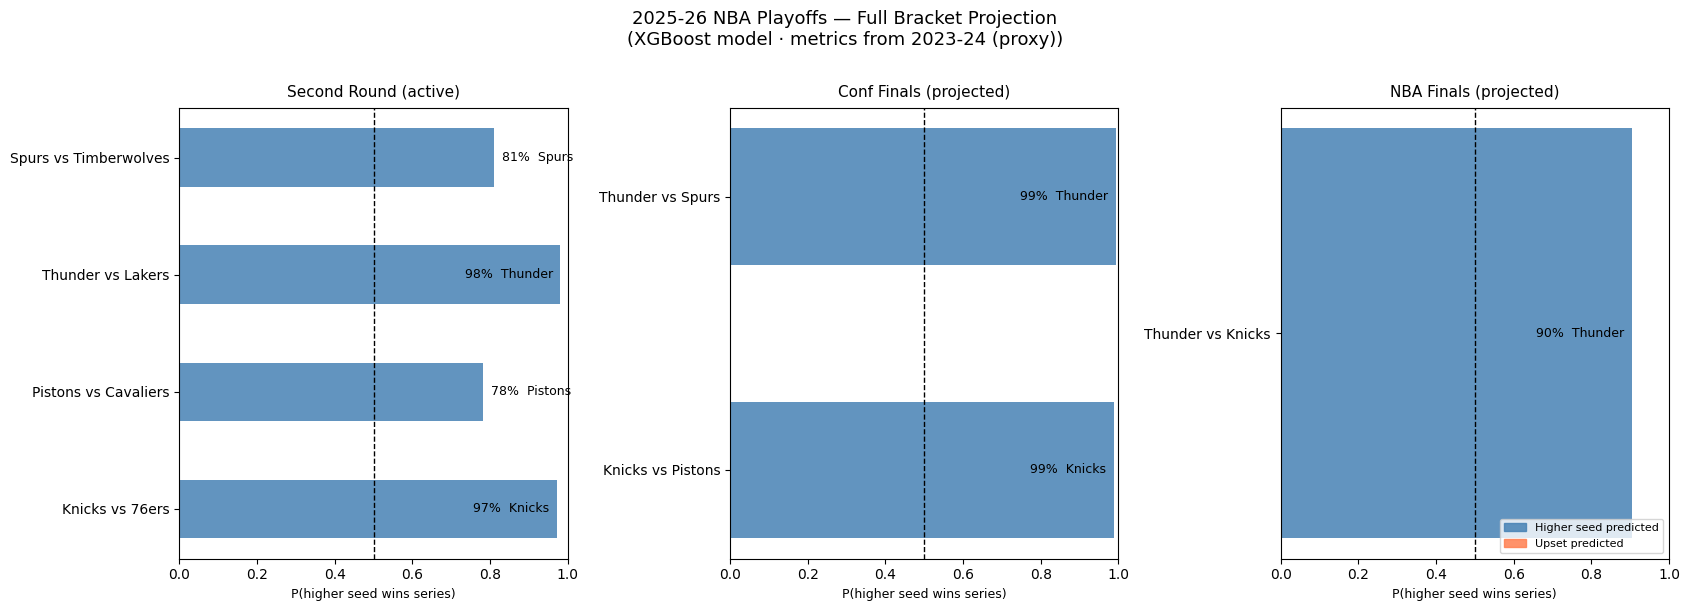

Saved → /Users/mearly/dev/playground/Sports/nba-playoffs/predictions_bracket_2025-26.png

  2025-26 NBA PLAYOFFS — FULL BRACKET PROJECTION

SECOND ROUND  (active)
  New York Knicks vs Philadelphia 76ers           → New York Knicks (97%)
  Detroit Pistons vs Cleveland Cavaliers          → Detroit Pistons (78%)
  Oklahoma City Thunder vs Los Angeles Lakers     → Oklahoma City Thunder (98%)
  San Antonio Spurs vs Minnesota Timberwolves     → San Antonio Spurs (81%)

CONFERENCE FINALS  (projected)
  [East CF]  New York Knicks vs Detroit Pistons       → New York Knicks (99%)
  [West CF]  Oklahoma City Thunder vs San Antonio Spurs→ Oklahoma City Thunder (99%)

NBA FINALS  (projected)
  Oklahoma City Thunder vs New York Knicks        → Oklahoma City Thunder (90%)

  *** PROJECTED CHAMPION: OKLAHOMA CITY THUNDER ***


In [9]:
def short_matchup(s):
    return " vs ".join(p.split()[-1] for p in s.split(" vs "))

all_rounds = [
    ("Second Round (active)",    pred_df),
    ("Conf Finals (projected)",  cf_df),
    ("NBA Finals (projected)",   finals_df),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(
    f"2025-26 NBA Playoffs — Full Bracket Projection\n(XGBoost model · metrics from {metrics_season})",
    fontsize=13, y=1.01,
)

for ax, (round_name, rdf) in zip(axes, all_rounds):
    labels = [short_matchup(m) for m in rdf["matchup"]]
    colors = ["steelblue" if p >= 0.5 else "coral" for p in rdf["prob_higher_seed"]]
    bars   = ax.barh(labels, rdf["prob_higher_seed"], color=colors, alpha=0.85, height=0.5)
    ax.axvline(0.5, color="black", linewidth=1.0, linestyle="--")
    ax.set_xlim(0, 1)
    ax.set_title(round_name, fontsize=11, pad=8)
    ax.set_xlabel("P(higher seed wins series)", fontsize=9)
    for bar, prob, name in zip(bars, rdf["prob_higher_seed"], rdf["predicted_winner"]):
        offset = 0.02 if prob < 0.85 else -0.02
        ha = "left" if prob < 0.85 else "right"
        ax.text(prob + offset, bar.get_y() + bar.get_height() / 2,
                f"{prob:.0%}  {name.split()[-1]}", va="center", ha=ha, fontsize=9)

higher = mpatches.Patch(color="steelblue", alpha=0.85, label="Higher seed predicted")
lower  = mpatches.Patch(color="coral",     alpha=0.85, label="Upset predicted")
axes[-1].legend(handles=[higher, lower], loc="lower right", fontsize=8)

plt.tight_layout()
out_path = Path().resolve().parent / "predictions_bracket_2025-26.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

# ── text bracket summary ─────────────────────────────────────
print("\n" + "=" * 62)
print("  2025-26 NBA PLAYOFFS — FULL BRACKET PROJECTION")
print("=" * 62)
print("\nSECOND ROUND  (active)")
for _, r in pred_df.iterrows():
    print(f"  {r['matchup']:<48}→ {r['predicted_winner']} ({r['confidence']})")
print("\nCONFERENCE FINALS  (projected)")
for (_, r), conf in zip(cf_df.iterrows(), ["East CF", "West CF"]):
    print(f"  [{conf}]  {r['matchup']:<41}→ {r['predicted_winner']} ({r['confidence']})")
print("\nNBA FINALS  (projected)")
r = finals_df.iloc[0]
print(f"  {r['matchup']:<48}→ {r['predicted_winner']} ({r['confidence']})")
print(f"\n  *** PROJECTED CHAMPION: {r['predicted_winner'].upper()} ***")
print("=" * 62)